In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
#pip install gensim


  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.1/24.4 MB 3.6 MB/s eta 0:00:07
    --------------------------------------- 0.5/24.4 MB 6.0 MB/s eta 0:00:04
   - -------------------------------------- 1.0/24.4 MB 7.0 MB/s eta 0:00:04
   -- ------------------------------------- 1.6/24.4 MB 7.7 MB/s eta 0:00:03
   -- ------------------------------------- 1.6/24.4 MB 8.1 MB/s eta 0:00:03
   --- ------------------------------------ 1.9/24.4 MB 6.6 MB/s eta 0:00:04
   --- ------------------------------------ 2.3/24.4 MB 7.3 MB/s eta 0:00:04
   ---- ----------------------------------- 2.9/24.4 MB 7.6 MB/s eta 0:00:03
   ----- ---------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df = pd.read_csv(r"/content/Reviews.csv")
# df.head()

texts = df["Text"].head(10).astype(str).tolist()
print(df["Text"].head(10))
print(texts)

labels = np.array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
5    I got a wild hair for taffy and ordered this f...
6    This saltwater taffy had great flavors and was...
7    This taffy is so good.  It is very soft and ch...
8    Right now I'm mostly just sprouting this so my...
9    This is a very healthy dog food. Good for thei...
Name: Text, dtype: object
['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.', 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended t

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

print("word Index: ")
print(tokenizer.word_index)

print("\n Sequences: ")
print(sequences)
# lengths = [len(seq) for seq in sequences]
# print(lengths)

word Index: 
{'the': 1, 'and': 2, 'this': 3, 'a': 4, 'it': 5, 'is': 6, 'i': 7, 'was': 8, 'very': 9, 'taffy': 10, 'of': 11, 'my': 12, 'good': 13, 'if': 14, 'with': 15, 'to': 16, 'product': 17, 'in': 18, 'recommend': 19, 'for': 20, 'have': 21, 'dog': 22, 'not': 23, 'too': 24, 'chewy': 25, 'treat': 26, 'you': 27, 'are': 28, 'great': 29, 'at': 30, 'flavors': 31, 'would': 32, 'food': 33, 'found': 34, 'all': 35, 'than': 36, 'better': 37, 'as': 38, 'jumbo': 39, 'peanuts': 40, 'were': 41, 'small': 42, 'that': 43, 'around': 44, 'into': 45, 'tiny': 46, 'highly': 47, 'yummy': 48, 'witch': 49, 'got': 50, 'root': 51, 'beer': 52, 'ordered': 53, 'which': 54, 'there': 55, 'only': 56, 'just': 57, 'soft': 58, 'candy': 59, 'so': 60, 'bought': 61, 'several': 62, 'vitality': 63, 'canned': 64, 'products': 65, 'them': 66, 'be': 67, 'quality': 68, 'looks': 69, 'more': 70, 'like': 71, 'stew': 72, 'processed': 73, 'meat': 74, 'smells': 75, 'labrador': 76, 'finicky': 77, 'she': 78, 'appreciates': 79, 'most': 80,

In [ ]:
max_length = 100

X = pad_sequences(
    sequences,
    maxlen = max_length,
    padding = "post"
)

print(X)

[[  7  21  61  62  11   1  63  64  22  33  65   2  21  34  66  35  16  67
   11  13  68   1  17  69  70  71   4  72  36   4  73  74   2   5  75  37
   12  76   6  77   2  78  79   3  17  37  36  80   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [ 17  81  82  38  39  83  40   1  40  41  84  42  85  86  23  87  14   3
    8  88  89  90  14   1  91  92  16  93   1  17  38  39   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  3   6   4  94  43  95  96  44   4  97  98   5   6   4  99 100 101 102
   15 103  18   3 104 105   2   5   6 106  45  46 107   2 108 109 110  15
  111 112   2   5   6   4 

In [ ]:
model = Sequential()

model.add(Embedding(
    input_dim = len(tokenizer.word_index) + 1,
    output_dim = 8,
    input_length = max_length
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(16))
model.add(Dense(1, activation = "sigmoid"))

In [ ]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
history = model.fit(
    X,
    labels,
    epochs = 20,
    verbose = 1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7000 - loss: 0.6153
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8000 - loss: 0.5040
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8000 - loss: 0.4831
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8000 - loss: 0.4704
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8000 - loss: 0.4548
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8000 - loss: 0.4118
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9000 - loss: 0.3117
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.2472
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9000 - loss: 0.2470
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.2018
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.1175
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.0933
Epo

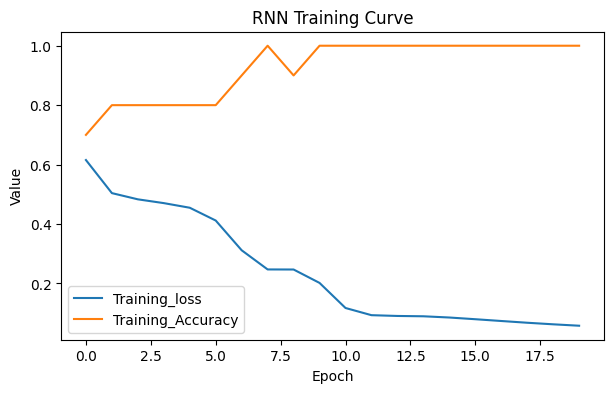

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (7,4))
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['accuracy'], label='Training_Accuracy')
plt.title("RNN Training Curve")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()